# 🏙️ City Brain — Exploratory Data Analysis (EDA)
**COMP9130 Final Project — Group 5**

**Objective:** Predict road failure risk in Vancouver using multimodal urban data.

This notebook performs EDA on the 8 datasets from our [GitHub repo](https://github.com/Ledja22/city-brain/tree/main/data), covering:
1. Data loading & cleaning
2. Per-dataset exploration (structure, distributions, missing values)
3. Geospatial visualization
4. Street infrastructure analysis
5. Construction & road closure temporal analysis
6. Cross-dataset joinability assessment
7. Gap analysis & next steps

---
## Part 0 — Environment Setup & Data Loading

In [ ]:
# Install dependencies (Colab has most of these, but just in case)
!pip install folium geopandas shapely -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap
import ast
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


In [ ]:
# Clone repo and load data
!git clone https://github.com/Ledja22/city-brain.git 2>/dev/null || echo 'Repo already cloned'

DATA_DIR = 'city-brain/data/'

df_streets = pd.read_csv(f'{DATA_DIR}public_streets.csv')
df_row = pd.read_csv(f'{DATA_DIR}right_of_way_widths.csv')
df_traffic_loc = pd.read_csv(f'{DATA_DIR}directional_traffic_count_locations.csv')
df_intersection = pd.read_csv(f'{DATA_DIR}intersection_traffic_movement_counts.csv')
df_projects = pd.read_csv(f'{DATA_DIR}city_project_package_street.csv')
df_closures = pd.read_csv(f'{DATA_DIR}road_ahead_current_road_closures.csv')
df_construction = pd.read_csv(f'{DATA_DIR}road_ahead_projects_under_construction.csv')
df_upcoming = pd.read_csv(f'{DATA_DIR}road_ahead_upcoming_projects.csv')

datasets = {
    'public_streets': df_streets,
    'right_of_way_widths': df_row,
    'directional_traffic_count_locations': df_traffic_loc,
    'intersection_traffic_movement_counts': df_intersection,
    'city_project_package_street': df_projects,
    'road_ahead_current_road_closures': df_closures,
    'road_ahead_projects_under_construction': df_construction,
    'road_ahead_upcoming_projects': df_upcoming
}

print('✅ All 8 datasets loaded.')
print()
for name, df in datasets.items():
    print(f'  {name}: {df.shape[0]:,} rows × {df.shape[1]} cols')

✅ All 8 datasets loaded.

  public_streets: 1,710 rows × 4 cols
  right_of_way_widths: 2,690 rows × 3 cols
  directional_traffic_count_locations: 670 rows × 3 cols
  intersection_traffic_movement_counts: 70 rows × 3 cols
  city_project_package_street: 40 rows × 6 cols
  road_ahead_current_road_closures: 10 rows × 7 cols
  road_ahead_projects_under_construction: 10 rows × 7 cols
  road_ahead_upcoming_projects: 30 rows × 7 cols


### Helper: Parse geo_point_2d to extract lat/lon

In [ ]:
def parse_geo_point(geo_str):
    """Parse geo_point_2d string like "{'lon': -123.xx, 'lat': 49.xx}" to (lat, lon)."""
    try:
        d = ast.literal_eval(geo_str)
        return d['lat'], d['lon']
    except:
        return np.nan, np.nan

def add_lat_lon(df, col='geo_point_2d'):
    """Add lat and lon columns to a dataframe."""
    if col in df.columns:
        coords = df[col].apply(parse_geo_point)
        df['lat'] = coords.apply(lambda x: x[0])
        df['lon'] = coords.apply(lambda x: x[1])
    return df

# Add lat/lon to all datasets that have geo_point_2d
for name, df in datasets.items():
    add_lat_lon(df)

print('✅ Lat/Lon extracted for all datasets.')

✅ Lat/Lon extracted for all datasets.


---
## Part 1 — Per-Dataset Overview
For each dataset: shape, dtypes, missing values, and sample rows.

In [ ]:
for name, df in datasets.items():
    print('=' * 70)
    print(f'📊 {name}')
    print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
    print(f'   Columns: {list(df.columns)}')
    print(f'   Dtypes:')
    for col in df.columns:
        if col not in ['lat', 'lon', 'geom', 'geo_point_2d']:
            print(f'      {col}: {df[col].dtype}')
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f'   ⚠️ Missing values:')
        for col in null_counts[null_counts > 0].index:
            print(f'      {col}: {null_counts[col]} ({null_counts[col]/len(df)*100:.1f}%)')
    else:
        print(f'   ✅ No missing values')
    print()

📊 public_streets
   Shape: 1710 rows × 6 columns
   Columns: ['geom', 'hblock', 'streetuse', 'geo_point_2d', 'lat', 'lon']
   Dtypes:
      hblock: object
      streetuse: object
   ✅ No missing values

📊 right_of_way_widths
   Shape: 2690 rows × 5 columns
   Columns: ['geom', 'width', 'geo_point_2d', 'lat', 'lon']
   Dtypes:
      width: float64
   ✅ No missing values

📊 directional_traffic_count_locations
   Shape: 670 rows × 5 columns
   Columns: ['location', 'geom', 'geo_point_2d', 'lat', 'lon']
   Dtypes:
      location: object
   ✅ No missing values

📊 intersection_traffic_movement_counts
   Shape: 70 rows × 3 columns
   Columns: ['geom', 'intersection', 'url']
   Dtypes:
      intersection: object
      url: object
   ✅ No missing values

📊 city_project_package_street
   Shape: 40 rows × 8 columns
   Columns: ['expected_completion_date', 'location', 'project_title', 'url_link', 'geom', 'geo_point_2d', 'lat', 'lon']
   Dtypes:
      expected_completion_date: object
      location

In [ ]:
# Summary table of all datasets
summary_data = []
for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Has Geo': 'geo_point_2d' in df.columns or 'geom' in df.columns,
        'Has Date': any('date' in c.lower() or 'comp' in c.lower() for c in df.columns),
        'Missing %': f"{df.isnull().mean().mean()*100:.1f}%"
    })

df_summary = pd.DataFrame(summary_data)
print('📋 Dataset Summary Table')
print()
display(df_summary)

📋 Dataset Summary Table



,Dataset,Rows,Columns,Has Geo,Has Date,Missing %
0,public_streets,1710,6,True,False,0.0%
1,right_of_way_widths,2690,5,True,False,0.0%
2,directional_traffic_count_locations,670,5,True,False,0.0%
3,intersection_traffic_movement_counts,70,3,True,False,0.0%
4,city_project_package_street,40,8,True,True,0.0%
5,road_ahead_current_road_closures,10,9,True,True,11.1%
6,road_ahead_projects_under_construction,10,9,True,True,13.3%
7,road_ahead_upcoming_projects,30,9,True,True,11.1%


---
## Part 2 — Geospatial Visualization
Plot all datasets on an interactive Vancouver map to understand spatial coverage.

In [ ]:
# Vancouver center coordinates
VAN_CENTER = [49.2827, -123.1207]

m = folium.Map(location=VAN_CENTER, zoom_start=12, tiles='CartoDB positron')

# --- Layer 1: Public Streets (colored by street use) ---
color_map = {'Arterial': '#e74c3c', 'Collector': '#f39c12', 'Residential': '#3498db'}

fg_streets = folium.FeatureGroup(name='Public Streets (by type)', show=True)
for _, row in df_streets.iterrows():
    try:
        geom = ast.literal_eval(row['geom'])
        coords = geom['geometry']['coordinates']
        street_type = row['streetuse']
        color = color_map.get(street_type, '#95a5a6')
        # Convert [lon, lat] to [lat, lon] for folium
        if geom['geometry']['type'] == 'LineString':
            line_coords = [[c[1], c[0]] for c in coords]
            folium.PolyLine(
                line_coords, color=color, weight=2, opacity=0.7,
                tooltip=f"{row['hblock']} ({street_type})"
            ).add_to(fg_streets)
    except:
        pass
fg_streets.add_to(m)

# --- Layer 2: Traffic Count Locations ---
fg_traffic = folium.FeatureGroup(name='Traffic Count Locations', show=True)
for _, row in df_traffic_loc.dropna(subset=['lat', 'lon']).iterrows():
    folium.CircleMarker(
        [row['lat'], row['lon']], radius=3, color='#2ecc71',
        fill=True, fill_opacity=0.7,
        tooltip=row['location']
    ).add_to(fg_traffic)
fg_traffic.add_to(m)

# --- Layer 3: Intersection Movement Counts ---
fg_inter = folium.FeatureGroup(name='Intersection Movement Counts', show=True)
for _, row in df_intersection.iterrows():
    try:
        geom = ast.literal_eval(row['geom'])
        lat = geom['geometry']['coordinates'][1]
        lon = geom['geometry']['coordinates'][0]
        folium.CircleMarker(
            [lat, lon], radius=5, color='#9b59b6',
            fill=True, fill_opacity=0.8,
            tooltip=row['intersection']
        ).add_to(fg_inter)
    except:
        pass
fg_inter.add_to(m)

# --- Layer 4: Construction & Closures ---
fg_works = folium.FeatureGroup(name='Road Works (closures + construction + upcoming)', show=True)
for label, df_work, icon_color in [
    ('🚧 Closure', df_closures, 'red'),
    ('🔨 Under Construction', df_construction, 'orange'),
    ('📋 Upcoming', df_upcoming, 'blue')
]:
    for _, row in df_work.dropna(subset=['lat', 'lon']).iterrows():
        loc_name = row.get('location', row.get('project', 'N/A'))
        folium.Marker(
            [row['lat'], row['lon']],
            tooltip=f"{label}: {loc_name}",
            icon=folium.Icon(color=icon_color, icon='wrench', prefix='fa')
        ).add_to(fg_works)
fg_works.add_to(m)

folium.LayerControl().add_to(m)

print('🗺️ Interactive Map of All Datasets in Vancouver')
m

🗺️ Interactive Map of All Datasets in Vancouver


---
## Part 3 — Street Infrastructure Analysis

### 3.1 Street Use Classification Distribution

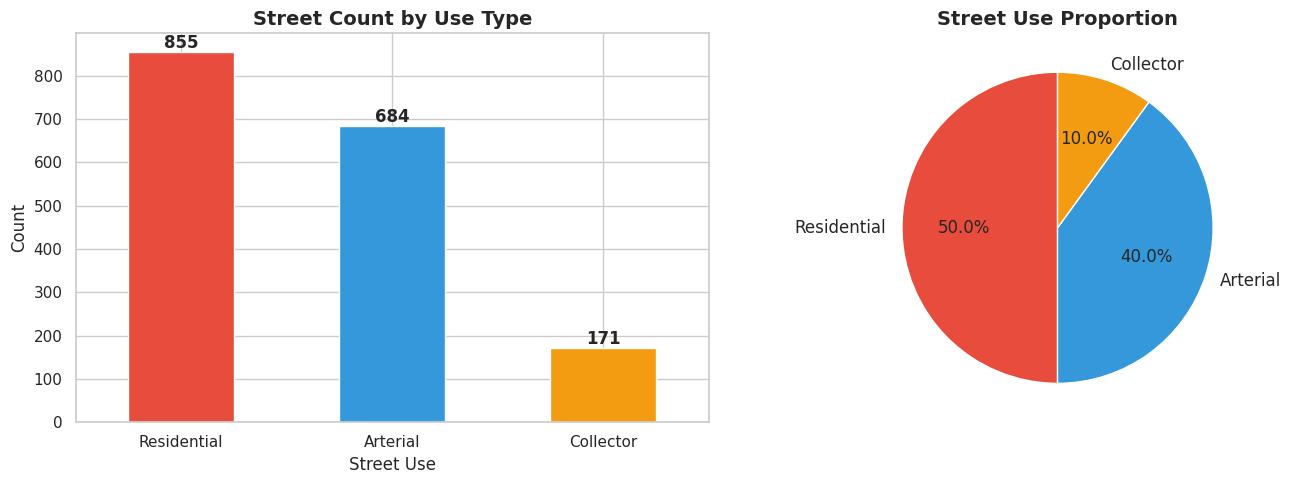

Total street segments: 1,710
  Residential: 855 (50.0%)
  Arterial:    684 (40.0%)
  Collector:   171 (10.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
street_counts = df_streets['streetuse'].value_counts()
colors = ['#e74c3c', '#3498db', '#f39c12']
street_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Street Count by Use Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Street Use')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(street_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
street_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
                   startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Street Use Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'Total street segments: {len(df_streets):,}')
print(f'  Residential: {street_counts.get("Residential", 0)} ({street_counts.get("Residential", 0)/len(df_streets)*100:.1f}%)')
print(f'  Arterial:    {street_counts.get("Arterial", 0)} ({street_counts.get("Arterial", 0)/len(df_streets)*100:.1f}%)')
print(f'  Collector:   {street_counts.get("Collector", 0)} ({street_counts.get("Collector", 0)/len(df_streets)*100:.1f}%)')

### 3.2 Right-of-Way Width Distribution

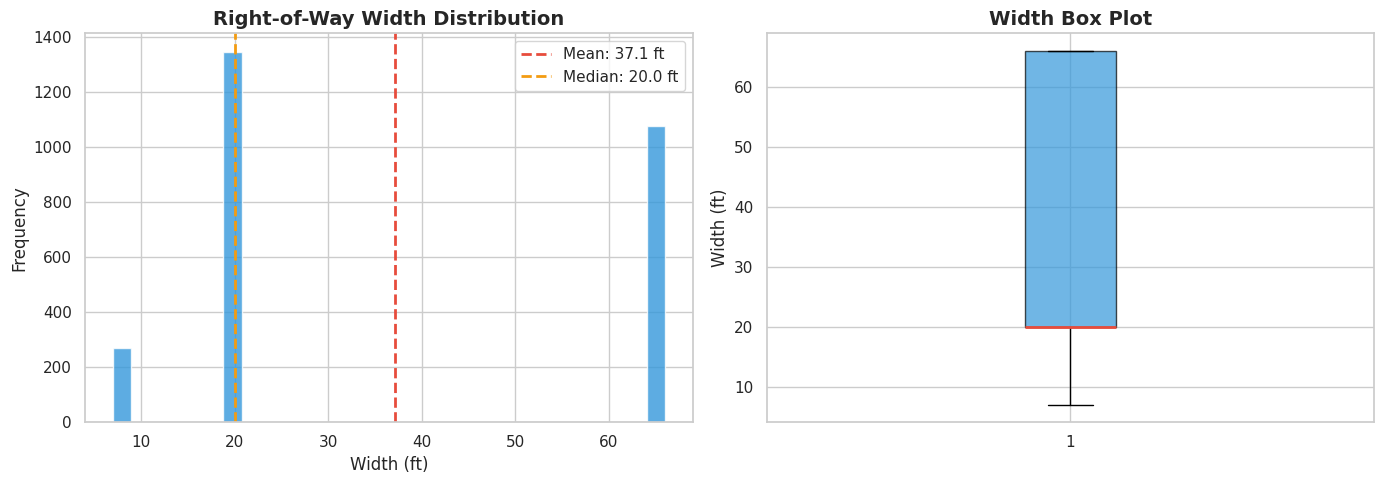

Width statistics:
  Min:    7 ft
  Max:    66 ft
  Mean:   37.1 ft
  Median: 20 ft
  Std:    23.9 ft

Value counts for top widths:
width
20.0    1345
66.0    1076
7.0      269
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_row['width'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df_row['width'].mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f"Mean: {df_row['width'].mean():.1f} ft")
axes[0].axvline(df_row['width'].median(), color='#f39c12', linestyle='--', linewidth=2, label=f"Median: {df_row['width'].median():.1f} ft")
axes[0].set_title('Right-of-Way Width Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width (ft)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df_row['width'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='#e74c3c', linewidth=2))
axes[1].set_title('Width Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Width (ft)')

plt.tight_layout()
plt.show()

print(f'Width statistics:')
print(f'  Min:    {df_row["width"].min():.0f} ft')
print(f'  Max:    {df_row["width"].max():.0f} ft')
print(f'  Mean:   {df_row["width"].mean():.1f} ft')
print(f'  Median: {df_row["width"].median():.0f} ft')
print(f'  Std:    {df_row["width"].std():.1f} ft')
print()
print('Value counts for top widths:')
print(df_row['width'].value_counts().head(10))

### 3.3 Right-of-Way Width Heatmap

In [ ]:
m_heat = folium.Map(location=VAN_CENTER, zoom_start=12, tiles='CartoDB dark_matter')

heat_data = df_row.dropna(subset=['lat', 'lon'])[['lat', 'lon', 'width']].values.tolist()
HeatMap(heat_data, radius=8, blur=12, max_zoom=15).add_to(m_heat)

print('🌡️ Right-of-Way Width Heatmap (wider roads = hotter spots)')
m_heat

🌡️ Right-of-Way Width Heatmap (wider roads = hotter spots)


### 3.4 Traffic Count Locations — Spatial Density

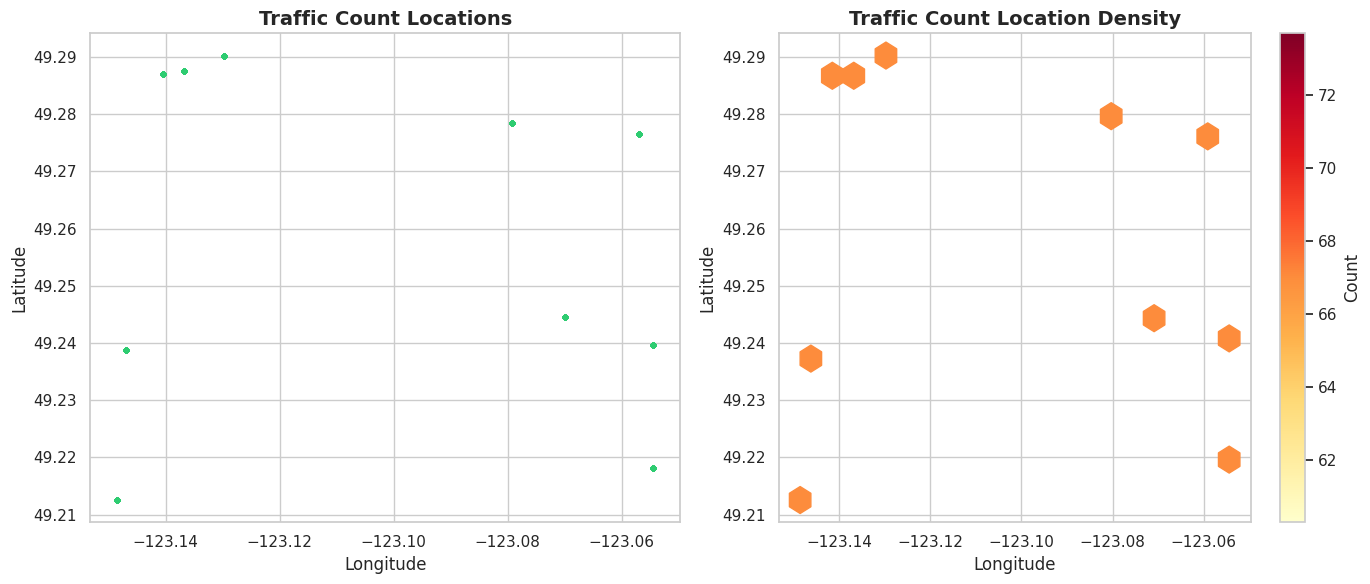

Total traffic count locations: 670

Top 10 streets with most traffic count points:
street_name
LANE             134
ANGUS DRIVE       67
VERNON DRIVE      67
SLOCAN ST         67
VENABLES ST       67
W PENDER ST       67
PINE CRESCENT     67
WELWYN ST         67
ELLIOTT ST        67
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot of traffic count locations
axes[0].scatter(df_traffic_loc['lon'], df_traffic_loc['lat'],
                alpha=0.5, s=10, c='#2ecc71')
axes[0].set_title('Traffic Count Locations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Hexbin density plot
hb = axes[1].hexbin(df_traffic_loc['lon'], df_traffic_loc['lat'],
                     gridsize=20, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Traffic Count Location Density', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

print(f'Total traffic count locations: {len(df_traffic_loc)}')

# Extract street names from location
df_traffic_loc['street_name'] = df_traffic_loc['location'].str.extract(r'\d+[-\s]*\d*\s+(.*)')
print(f'\nTop 10 streets with most traffic count points:')
print(df_traffic_loc['street_name'].value_counts().head(10))

---
## Part 4 — Construction & Road Closure Analysis

### 4.1 Combine Road Works Data

In [ ]:
# Standardize and combine
df_closures_copy = df_closures.copy()
df_closures_copy['status'] = 'Closed'

df_construction_copy = df_construction.copy()
df_construction_copy['status'] = 'Under Construction'

df_upcoming_copy = df_upcoming.copy()
df_upcoming_copy['status'] = 'Upcoming'

df_projects_copy = df_projects.copy()
df_projects_copy['status'] = 'City Project'
df_projects_copy = df_projects_copy.rename(columns={'expected_completion_date': 'comp_date', 'project_title': 'project'})

# Combine into one
common_cols = ['project', 'location', 'comp_date', 'status', 'lat', 'lon']

for df_temp in [df_closures_copy, df_construction_copy, df_upcoming_copy, df_projects_copy]:
    for col in common_cols:
        if col not in df_temp.columns:
            df_temp[col] = np.nan

df_all_works = pd.concat([
    df_closures_copy[common_cols],
    df_construction_copy[common_cols],
    df_upcoming_copy[common_cols],
    df_projects_copy[common_cols]
], ignore_index=True)

df_all_works['comp_date'] = pd.to_datetime(df_all_works['comp_date'], errors='coerce')

print(f'Combined road works: {len(df_all_works)} records')
print()
print(df_all_works['status'].value_counts())

Combined road works: 90 records

status
City Project          40
Upcoming              30
Under Construction    10
Closed                10
Name: count, dtype: int64


### 4.2 Project Completion Timeline

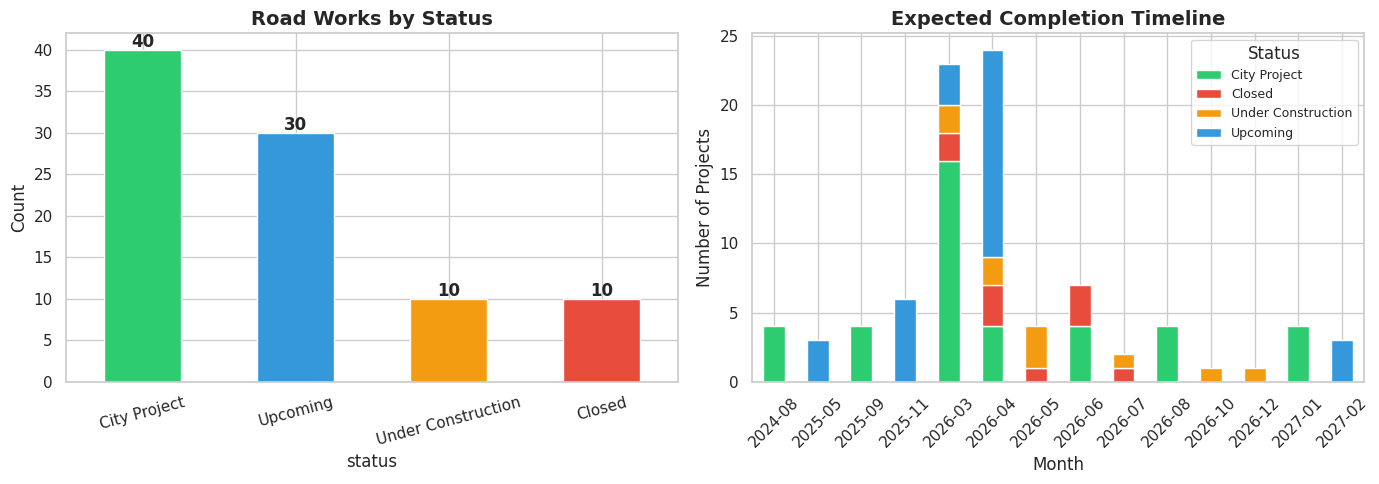


Completion date range: 2024-08-28 to 2027-02-02


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Status distribution
status_colors = {'Closed': '#e74c3c', 'Under Construction': '#f39c12',
                 'Upcoming': '#3498db', 'City Project': '#2ecc71'}
status_counts = df_all_works['status'].value_counts()
status_counts.plot(kind='bar', ax=axes[0],
                   color=[status_colors.get(s, '#95a5a6') for s in status_counts.index],
                   edgecolor='white')
axes[0].set_title('Road Works by Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(status_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Timeline
df_timeline = df_all_works.dropna(subset=['comp_date']).copy()
df_timeline['year_month'] = df_timeline['comp_date'].dt.to_period('M')
timeline_counts = df_timeline.groupby(['year_month', 'status']).size().unstack(fill_value=0)
timeline_counts.plot(kind='bar', stacked=True, ax=axes[1],
                     color=[status_colors.get(c, '#95a5a6') for c in timeline_counts.columns])
axes[1].set_title('Expected Completion Timeline', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Projects')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Status', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nCompletion date range: {df_timeline["comp_date"].min().strftime("%Y-%m-%d")} to {df_timeline["comp_date"].max().strftime("%Y-%m-%d")}')

### 4.3 Road Works Spatial Distribution

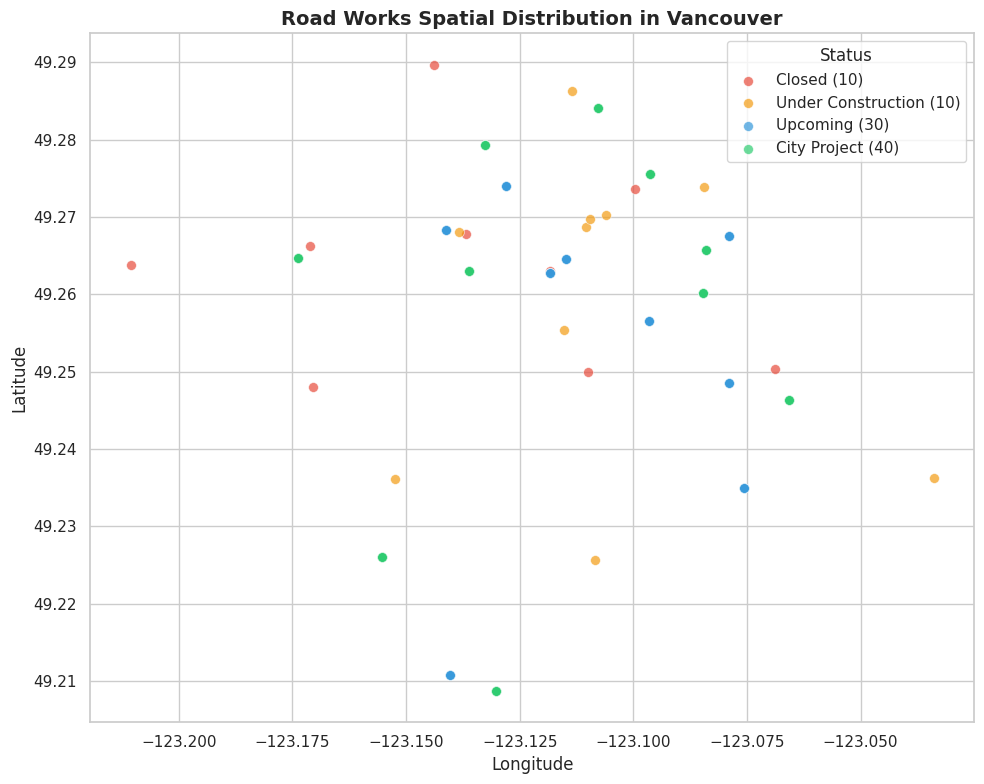

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for status in df_all_works['status'].unique():
    subset = df_all_works[df_all_works['status'] == status].dropna(subset=['lat', 'lon'])
    ax.scatter(subset['lon'], subset['lat'],
               label=f"{status} ({len(subset)})",
               color=status_colors.get(status, '#95a5a6'),
               alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

ax.set_title('Road Works Spatial Distribution in Vancouver', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Status')
plt.tight_layout()
plt.show()

---
## Part 5 — Cross-Dataset Joinability Assessment
A critical step: can we actually link these datasets together for modeling?

In [ ]:
from scipy.spatial import cKDTree

def spatial_join_assessment(df1, name1, df2, name2, threshold_m=100):
    """
    Assess how many points in df1 can be matched to points in df2
    within a given distance threshold (in meters).
    Uses approximate conversion: 1 degree ≈ 111,000 meters.
    """
    sub1 = df1.dropna(subset=['lat', 'lon'])[['lat', 'lon']].values
    sub2 = df2.dropna(subset=['lat', 'lon'])[['lat', 'lon']].values

    if len(sub1) == 0 or len(sub2) == 0:
        return 0, 0

    # Convert to approximate meters for distance threshold
    threshold_deg = threshold_m / 111000

    tree = cKDTree(sub2)
    distances, _ = tree.query(sub1)
    matched = np.sum(distances < threshold_deg)

    return matched, len(sub1)

# Add lat/lon to df_intersection if not already present
# The 'geom' column in df_intersection has coordinates in [lon, lat] format
if 'lat' not in datasets['intersection_traffic_movement_counts'].columns:
    def extract_lat_lon_from_intersection_geom(geom_str):
        try:
            geom_dict = ast.literal_eval(geom_str)
            if geom_dict and 'geometry' in geom_dict and 'coordinates' in geom_dict['geometry']:
                lon = geom_dict['geometry']['coordinates'][0]
                lat = geom_dict['geometry']['coordinates'][1]
                return lat, lon
        except (ValueError, SyntaxError, TypeError, KeyError):
            pass
        return np.nan, np.nan

    coords = datasets['intersection_traffic_movement_counts']['geom'].apply(extract_lat_lon_from_intersection_geom)
    datasets['intersection_traffic_movement_counts']['lat'] = coords.apply(lambda x: x[0])
    datasets['intersection_traffic_movement_counts']['lon'] = coords.apply(lambda x: x[1])
    print('✅ Lat/Lon extracted for intersection_traffic_movement_counts from geom column.')

print('🔗 Cross-Dataset Spatial Join Assessment')
print(f'   (Threshold: 100 meters)')
print()

pairs = [
    ('public_streets', 'right_of_way_widths'),
    ('public_streets', 'directional_traffic_count_locations'),
    ('public_streets', 'intersection_traffic_movement_counts'),
    ('directional_traffic_count_locations', 'road_ahead_current_road_closures'),
    ('directional_traffic_count_locations', 'road_ahead_projects_under_construction'),
    ('right_of_way_widths', 'road_ahead_current_road_closures'),
]

results = []
for n1, n2 in pairs:
    matched, total = spatial_join_assessment(datasets[n1], n1, datasets[n2], n2)
    pct = matched / total * 100 if total > 0 else 0
    results.append({'Dataset A': n1, 'Dataset B': n2,
                    'A rows': total, 'Matched': matched, 'Match %': f'{pct:.1f}%'})
    print(f'  {n1} → {n2}: {matched}/{total} matched ({pct:.1f}%)')

print()
display(pd.DataFrame(results))

✅ Lat/Lon extracted for intersection_traffic_movement_counts from geom column.
🔗 Cross-Dataset Spatial Join Assessment
   (Threshold: 100 meters)

  public_streets → right_of_way_widths: 0/1710 matched (0.0%)
  public_streets → directional_traffic_count_locations: 0/1710 matched (0.0%)
  public_streets → intersection_traffic_movement_counts: 0/1710 matched (0.0%)
  directional_traffic_count_locations → road_ahead_current_road_closures: 0/670 matched (0.0%)
  directional_traffic_count_locations → road_ahead_projects_under_construction: 0/670 matched (0.0%)
  right_of_way_widths → road_ahead_current_road_closures: 0/2690 matched (0.0%)



,Dataset A,Dataset B,A rows,Matched,Match %
0,public_streets,right_of_way_widths,1710,0,0.0%
1,public_streets,directional_traffic_count_locations,1710,0,0.0%
2,public_streets,intersection_traffic_movement_counts,1710,0,0.0%
3,directional_traffic_count_locations,road_ahead_current_road_closures,670,0,0.0%
4,directional_traffic_count_locations,road_ahead_projects_under_construction,670,0,0.0%
5,right_of_way_widths,road_ahead_current_road_closures,2690,0,0.0%


### 5.1 Join Key Analysis

In [ ]:
print('🔑 Potential Join Keys Across Datasets')
print('=' * 60)
print()
print('1. Geospatial (lat/lon) — Available in ALL datasets ✅')
print('   → Primary join method: spatial proximity matching')
print('   → Challenge: need to define appropriate distance threshold')
print()
print('2. Street Name — Partial availability ⚠️')
print(f'   public_streets.hblock: {df_streets["hblock"].nunique()} unique values')
print(f'   traffic_locations.location: {df_traffic_loc["location"].nunique()} unique values')
print(f'   intersection.intersection: {df_intersection["intersection"].nunique()} unique values')
print('   → Challenge: inconsistent naming ("OAK ST" vs "Oak Street")')
print()
print('3. Date/Time — Limited ⚠️')
print(f'   road_works comp_date range: {df_all_works["comp_date"].min()} to {df_all_works["comp_date"].max()}')
print('   → Only available for construction/closure datasets')
print()
print('4. No unified road segment ID ❌')
print('   → This is the biggest gap — no shared ID across datasets')
print('   → Proposal should address this: use geo-matching to create synthetic road IDs')

🔑 Potential Join Keys Across Datasets

1. Geospatial (lat/lon) — Available in ALL datasets ✅
   → Primary join method: spatial proximity matching
   → Challenge: need to define appropriate distance threshold

2. Street Name — Partial availability ⚠️
   public_streets.hblock: 10 unique values
   traffic_locations.location: 10 unique values
   intersection.intersection: 10 unique values
   → Challenge: inconsistent naming ("OAK ST" vs "Oak Street")

3. Date/Time — Limited ⚠️
   road_works comp_date range: 2024-08-28 00:00:00 to 2027-02-02 00:00:00
   → Only available for construction/closure datasets

4. No unified road segment ID ❌
   → This is the biggest gap — no shared ID across datasets
   → Proposal should address this: use geo-matching to create synthetic road IDs


---
## Part 6 — Correlation & Feature Preview
Preview what features we can extract for modeling.

In [ ]:
# For street segments, try to match width and traffic count data
from scipy.spatial import cKDTree

# Get street midpoints
streets_with_coords = df_streets.dropna(subset=['lat', 'lon']).copy()

# Match each street to nearest ROW width
row_coords = df_row.dropna(subset=['lat', 'lon'])[['lat', 'lon']].values
row_widths = df_row.dropna(subset=['lat', 'lon'])['width'].values
tree_row = cKDTree(row_coords)

street_coords = streets_with_coords[['lat', 'lon']].values
dist_row, idx_row = tree_row.query(street_coords)
streets_with_coords['nearest_row_width'] = row_widths[idx_row]
streets_with_coords['row_distance'] = dist_row * 111000  # approx meters

# Match each street to nearest traffic count location
traffic_coords = df_traffic_loc.dropna(subset=['lat', 'lon'])[['lat', 'lon']].values
tree_traffic = cKDTree(traffic_coords)
dist_traffic, _ = tree_traffic.query(street_coords)
streets_with_coords['dist_to_traffic_count'] = dist_traffic * 111000

# Match to nearest road work
works_coords = df_all_works.dropna(subset=['lat', 'lon'])[['lat', 'lon']].values
if len(works_coords) > 0:
    tree_works = cKDTree(works_coords)
    dist_works, _ = tree_works.query(street_coords)
    streets_with_coords['dist_to_road_work'] = dist_works * 111000

print('📊 Feature-enriched street dataset preview:')
display(streets_with_coords[['hblock', 'streetuse', 'nearest_row_width',
                              'row_distance', 'dist_to_traffic_count',
                              'dist_to_road_work']].head(10))

📊 Feature-enriched street dataset preview:


,hblock,streetuse,nearest_row_width,row_distance,dist_to_traffic_count,dist_to_road_work
0,2700 E 22ND AV,Collector,20.0,2793.545975,1408.215623,2035.240845
1,700 W HASTINGS ST,Arterial,66.0,2725.817767,1783.384205,131.605957
2,1200 ROBSON ST,Arterial,66.0,3312.349159,508.612530,974.934462
3,1300 HARO ST,Residential,66.0,3535.934324,393.940825,874.095546
4,600-700 MALKIN AV,Residential,7.0,2776.971319,1130.772129,500.000476
5,1900 CASSIAR ST,Residential,66.0,1538.937152,3071.551216,3417.632321
6,2800 E 6TH AV,Residential,66.0,2688.278971,1889.752801,3114.202214
7,2300 NANAIMO ST,Arterial,66.0,3928.508552,1449.277904,1993.067420
8,3500 W 49TH AV,Residential,66.0,8893.386615,4255.862175,2725.895396
9,1300 W KING EDWARD AV,Arterial,66.0,3006.801964,1727.054803,1524.159871


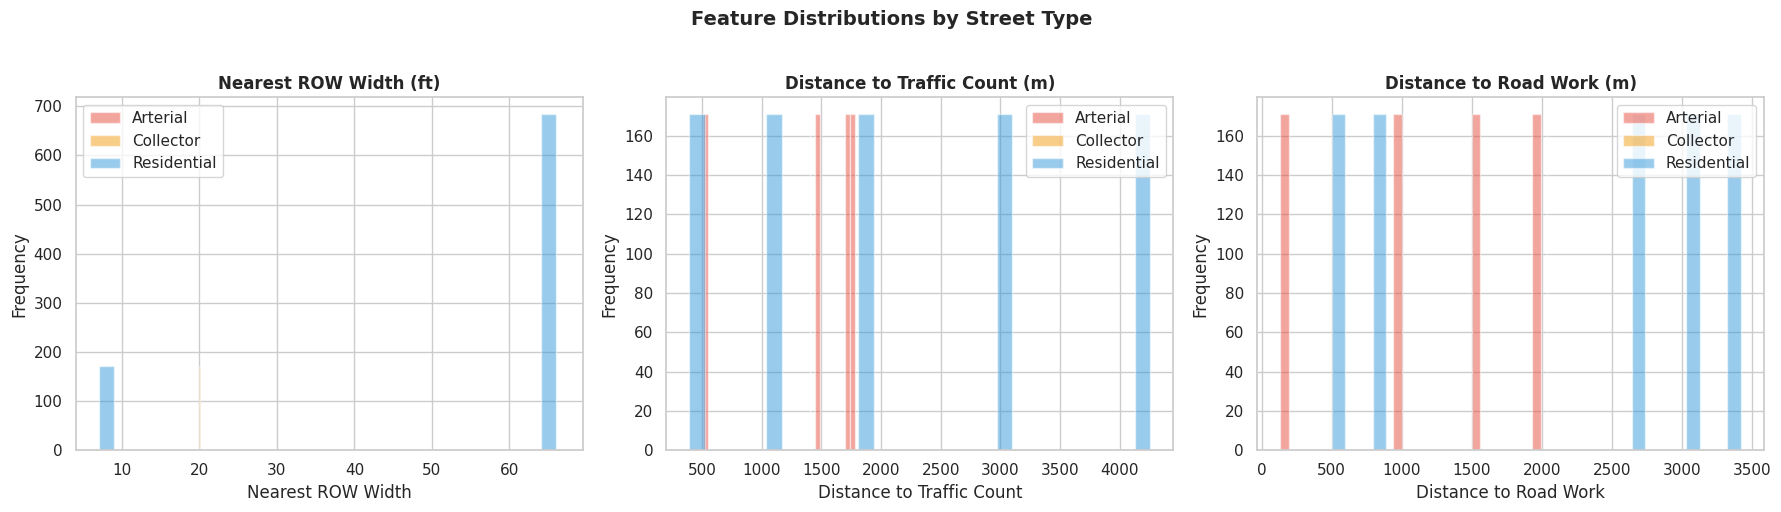

In [ ]:
# Feature distributions by street use type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes,
    ['nearest_row_width', 'dist_to_traffic_count', 'dist_to_road_work'],
    ['Nearest ROW Width (ft)', 'Distance to Traffic Count (m)', 'Distance to Road Work (m)']):
    for stype in ['Arterial', 'Collector', 'Residential']:
        subset = streets_with_coords[streets_with_coords['streetuse'] == stype]
        ax.hist(subset[col], bins=30, alpha=0.5, label=stype,
                color=color_map[stype])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title.split('(')[0].strip())
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Street Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

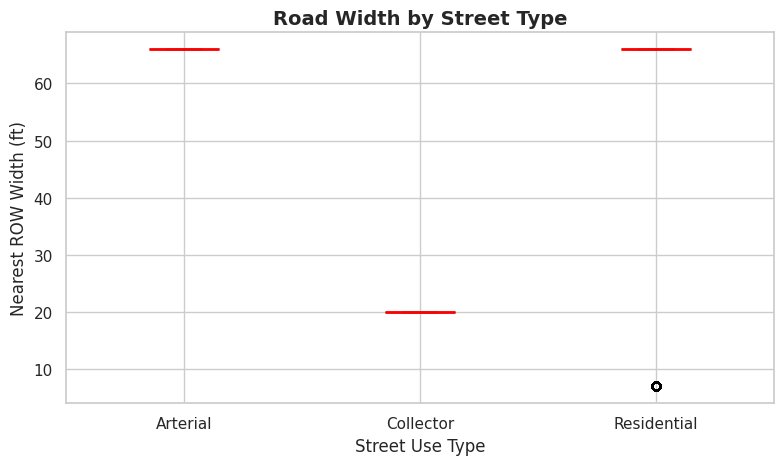

Width statistics by street type:


,count,mean,std,min,25%,50%,75%,max
streetuse,,,,,,,,
Arterial,684.0,66.0,0.0,66.0,66.0,66.0,66.0,66.0
Collector,171.0,20.0,0.0,20.0,20.0,20.0,20.0,20.0
Residential,855.0,54.2,23.6,7.0,66.0,66.0,66.0,66.0


In [ ]:
# Width distribution by street type — boxplot
fig, ax = plt.subplots(figsize=(8, 5))
streets_with_coords.boxplot(column='nearest_row_width', by='streetuse', ax=ax,
                            patch_artist=True,
                            boxprops=dict(alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
ax.set_title('Road Width by Street Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Street Use Type')
ax.set_ylabel('Nearest ROW Width (ft)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Width statistics by street type:')
display(streets_with_coords.groupby('streetuse')['nearest_row_width'].describe().round(1))

---
## Part 7 — Gap Analysis & Next Steps
### What we have vs. what the proposal needs

In [ ]:
print('=' * 70)
print('📋 DATA GAP ANALYSIS')
print('=' * 70)
print()
print('✅ AVAILABLE in GitHub repo (8 datasets):')
print('   • Public streets with classification (Arterial/Collector/Residential)')
print('   • Right-of-way widths (road width measurements)')
print('   • Directional traffic count locations (670 points)')
print('   • Intersection traffic movement counts (70 intersections)')
print('   • City project packages (40 projects)')
print('   • Current road closures, under construction, upcoming projects')
print()
print('❌ MISSING — Required by proposal but NOT in repo:')
print('   1. Pavement Condition Index (PCI) scores')
print('      → Source: https://opendata.vancouver.ca/explore/dataset/street-condition/')
print('      → THIS IS THE TARGET VARIABLE — must be acquired!')
print()
print('   2. 311 Service Requests (pothole complaints, road repair requests)')
print('      → Source: https://opendata.vancouver.ca/explore/dataset/3-1-1-service-requests/')
print('      → Critical for "complaint density" feature')
print()
print('   3. Weather / Climate data')
print('      → Source: Environment Canada historical weather data')
print('      → Needed for freeze-thaw cycles, precipitation features')
print()
print('   4. Actual traffic volume counts (not just locations)')
print('      → Current data only has WHERE counts happen, not the actual counts')
print('      → May need to scrape from the URLs in intersection dataset')
print()
print('⚠️ KEY CHALLENGES:')
print('   • No unified road segment ID across datasets')
print('   • Will need spatial joins (geo-matching) to link datasets')
print('   • Street name formats are inconsistent across datasets')
print('   • Road works data is small (90 total records)')
print()
print('📝 RECOMMENDED NEXT STEPS:')
print('   1. Download PCI dataset from Vancouver Open Data (PRIORITY #1)')
print('   2. Download 311 Service Requests, filter for road-related categories')
print('   3. Download Environment Canada weather data for Vancouver')
print('   4. Build spatial join pipeline to create unified road segments')
print('   5. Re-run EDA with complete feature set')

📋 DATA GAP ANALYSIS

✅ AVAILABLE in GitHub repo (8 datasets):
   • Public streets with classification (Arterial/Collector/Residential)
   • Right-of-way widths (road width measurements)
   • Directional traffic count locations (670 points)
   • Intersection traffic movement counts (70 intersections)
   • City project packages (40 projects)
   • Current road closures, under construction, upcoming projects

❌ MISSING — Required by proposal but NOT in repo:
   1. Pavement Condition Index (PCI) scores
      → Source: https://opendata.vancouver.ca/explore/dataset/street-condition/
      → THIS IS THE TARGET VARIABLE — must be acquired!

   2. 311 Service Requests (pothole complaints, road repair requests)
      → Source: https://opendata.vancouver.ca/explore/dataset/3-1-1-service-requests/
      → Critical for "complaint density" feature

   3. Weather / Climate data
      → Source: Environment Canada historical weather data
      → Needed for freeze-thaw cycles, precipitation features

   

In [ ]:
# Final summary statistics
print('=' * 70)
print('📊 EDA SUMMARY STATISTICS')
print('=' * 70)
print(f'\nTotal datasets analyzed: 8')
print(f'Total records across all datasets: {sum(len(df) for df in datasets.values()):,}')
print(f'\nGeographic coverage:')
all_lats = pd.concat([df.dropna(subset=['lat'])['lat'] for df in datasets.values()])
all_lons = pd.concat([df.dropna(subset=['lon'])['lon'] for df in datasets.values()])
print(f'  Latitude range:  {all_lats.min():.4f} to {all_lats.max():.4f}')
print(f'  Longitude range: {all_lons.min():.4f} to {all_lons.max():.4f}')
print(f'\nStreet infrastructure:')
print(f'  Total street segments: {len(df_streets):,}')
print(f'  ROW width data points: {len(df_row):,}')
print(f'  Traffic count locations: {len(df_traffic_loc)}')
print(f'\nRoad works (repair proxy):')
print(f'  Total road work records: {len(df_all_works)}')
print(f'  Currently closed: {len(df_closures)}')
print(f'  Under construction: {len(df_construction)}')
print(f'  Upcoming projects: {len(df_upcoming)}')
print(f'  City projects: {len(df_projects)}')

📊 EDA SUMMARY STATISTICS

Total datasets analyzed: 8
Total records across all datasets: 5,230

Geographic coverage:
  Latitude range:  49.2087 to 49.2926
  Longitude range: -123.2106 to -123.0137

Street infrastructure:
  Total street segments: 1,710
  ROW width data points: 2,690
  Traffic count locations: 670

Road works (repair proxy):
  Total road work records: 90
  Currently closed: 10
  Under construction: 10
  Upcoming projects: 30
  City projects: 40
